In [27]:
import pandas as pd

In [28]:
df=pd.read_csv(r'D:\Enterprise_ITSM_AI\data\raw\itsm_cleaned_dataset.csv')

In [29]:
# Features
X = df[
    [
        "contact_type",
        "location",
        "u_symptom",
        "knowledge",
        "notify",
        "opened_hour",
        "opened_day_of_week",
        "opened_month",
        "is_weekend"
    ]
]

# Target
y = df["priority"]

In [30]:
y.value_counts()

priority
3 - Moderate    132452
4 - Low           4030
2 - High          2972
1 - Critical      2258
Name: count, dtype: int64

Applying label encoder on target variable

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [32]:
mapping = pd.DataFrame({
    "Priority": le.classes_,
    "Encoded": range(len(le.classes_))
})

print(mapping)

       Priority  Encoded
0  1 - Critical        0
1      2 - High        1
2  3 - Moderate        2
3       4 - Low        3


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

ML pipeline 

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [35]:
import xgboost
from xgboost import XGBClassifier

In [38]:
preprocessing_data = ColumnTransformer(
    transformers=[
        (
            'trf1',
            OneHotEncoder(handle_unknown='ignore'),
            ['contact_type', 'location', 'u_symptom', 'notify', 'opened_day_of_week']
        )
    ],
    remainder='passthrough'
)

dt_pipeline = Pipeline([
    ('preprocessor', preprocessing_data),
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessing_data),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessing_data),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ))
])

In [39]:
dt_pipeline.fit(X_train,y_train)
rf_pipeline.fit(X_train,y_train)
xgboost_pipeline.fit(X_train,y_train)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf1',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['contact_type', 'location',
                                                   'u_symptom', 'notify',
                                                   'opened_day_of_week'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [40]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [41]:
results={}
def evaluate_model(name,model,X_test,y_test):
    y_pred=model.predict(X_test)
    metrics={
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    }
    results[name]=metrics

In [42]:
evaluate_model("Decision Tree", dt_pipeline, X_test, y_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test)
evaluate_model("XGBoost", xgboost_pipeline, X_test, y_test)

c:\Users\bharg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
results_df=pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df)

               Accuracy  Precision  Recall  F1 Score
Decision Tree    0.9684     0.8301  0.7596    0.7915
Random Forest    0.9349     0.4837  0.2519    0.2453
XGBoost          0.9465     0.8715  0.4063    0.4938


Predictions are more accurate,sign of red flag,checking whether we can reconstruct priority from impact and urgency

In [ ]:
pd.crosstab(
    [df["impact"], df["urgency"]],
    df["priority"]
)

priority               1 - Critical  2 - High  3 - Moderate  4 - Low
impact     urgency                                                  
1 - High   1 - High            2258         0             0        0
           2 - Medium             0      1233             0        0
2 - Medium 1 - High               0      1739             0        0
           2 - Medium             0         0        132429        0
           3 - Low                0         0             0      167
3 - Low    1 - High               0         0            23        0
           2 - Medium             0         0             0      432
           3 - Low                0         0             0     3431

Every (Impact, Urgency) combination maps to exactly one Priority.
That means:
Priority=f(Impact,Urgency)
The model simply memorized this deterministic business rule.

So lets continue by removing impact and urgency

           Accuracy  Precision  Recall  F1 Score

Decision Tree    0.9684     0.8301  0.7596    0.7915Random Forest    0.9349     0.4837  0.2519    0.2453XGBoost          0.9465     0.8715  0.4063    0.4938

After removing the leaked features (impact and urgency), the models were retrained. The Decision Tree classifier achieved the best performance with 96.84% accuracy and a Macro F1-score of 0.7915, outperforming both Random Forest and XGBoost.

Saving the model and encoder

In [44]:
import joblib

In [45]:
joblib.dump(
    dt_pipeline,
    r"D:\Enterprise_ITSM_AI\models_saved\priority_prediction_pipeline.joblib"
)

joblib.dump(
    le,
    r"D:\Enterprise_ITSM_AI\models_saved\priority_label_encoder.joblib"
)

['D:\\Enterprise_ITSM_AI\\models_saved\\priority_label_encoder.joblib']

In [46]:
results_df.to_csv(
    r"D:\Enterprise_ITSM_AI\models_saved\priority_model_results.csv",
    index=True
)

In [47]:
feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [48]:
dt_model = dt_pipeline.named_steps["model"]

In [49]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [50]:
feature_importance.to_csv(
    r"D:\Enterprise_ITSM_AI\models_saved\priority_feature_importance.csv",
    index=False
)

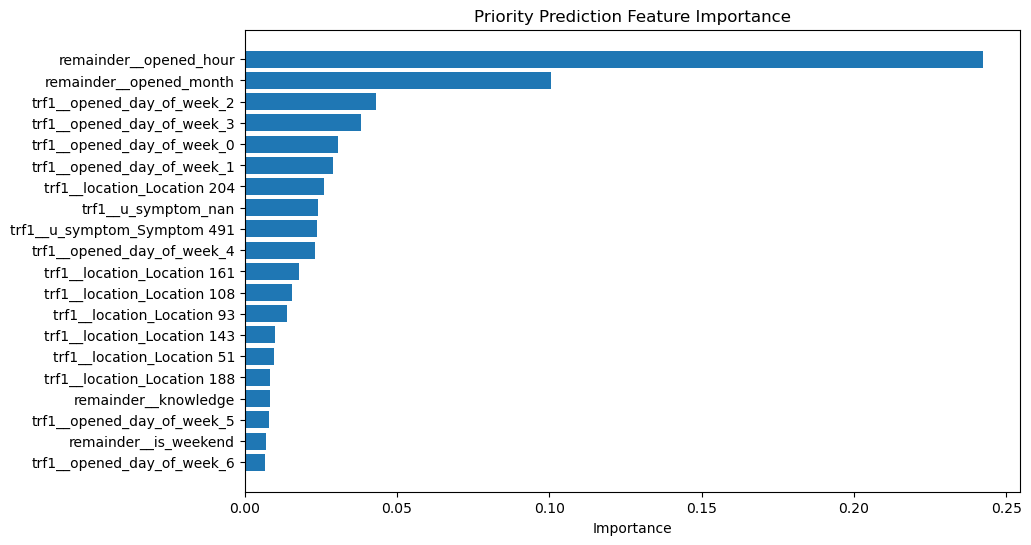

In [51]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Priority Prediction Feature Importance")
plt.xlabel("Importance")

plt.savefig(
    r"D:\Enterprise_ITSM_AI\models_saved\priority_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [52]:
plt.savefig(
    r"D:\Enterprise_ITSM_AI\models_saved\priority_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>